# Notebook 07: Fine-Tuning the Sentence Encoder
## Unfreezing `all-MiniLM-L6-v2` for Hedging Language Detection

### Purpose
All prior experiments (Notebooks 04–06) used a frozen `all-MiniLM-L6-v2` encoder
— embeddings were computed once and reused across all augmentation conditions.
The consistent finding was that the encoder, not the augmentation strategy or
the classifier head, was the primary bottleneck. Calibrated F1 under the frozen
regime peaked at 0.179.

This notebook tests that hypothesis directly by unfreezing and fine-tuning the
encoder end-to-end on the hedging classification task.

### Experimental Design
Fine-tuning is performed in stages, unfreezing progressively deeper layers:

| Condition | Unfrozen Layers | Trainable Parameters |
|-----------|----------------|----------------------|
| Frozen baseline | None | 0 |
| Stage 1 | Last transformer layer + pooling | ~1.2M |
| Stage 2 | Top 2 transformer layers + pooling | ~2.4M |
| Stage 3 | Top 3 transformer layers + pooling | ~3.6M |
| Full fine-tune | All layers | ~22M |

Each condition is evaluated independently:
- Embeddings recomputed from scratch after fine-tuning
- LR classifier retrained with `class_weight='balanced'`
- Venn-Abers calibration fitted on calibration set
- Threshold optimized on calibration set, applied to test set
- Frozen baseline artifacts loaded for direct comparison

### Design Choices

**Loss function: Cross-entropy with class weights**
Classification loss was chosen over contrastive loss (e.g.
MultipleNegativesRankingLoss) for two reasons: (1) it directly optimizes
the same objective as the downstream LR classifier, making the fine-tuning
signal consistent with the evaluation criterion; and (2) it is computationally
lightweight — no pair construction overhead, runs feasibly on CPU, and
compatible with the existing class imbalance handling via `class_weight`.
Contrastive loss is reserved as a follow-up experiment if classification
loss plateaus.

**Staged unfreezing**
Full fine-tuning of all 22M parameters on 962 positive examples carries
significant overfitting risk. Staged unfreezing limits trainable parameters
at each step, allowing us to identify the unfreezing depth at which
calibrated F1 peaks before committing to deeper fine-tuning.

**Early stopping on calibrated F1**
Training loss and raw F1 are unreliable stopping criteria under 100:1
class imbalance — a model can minimize cross-entropy while collapsing
to the majority class. Early stopping is applied to calibrated F1 on
the calibration set, consistent with the evaluation framework used
throughout this project.

**Learning rate: 2e-5**
Standard for transformer fine-tuning. Lower than typical classification
fine-tuning (1e-4) to avoid catastrophic forgetting of pretrained
representations, particularly important for shallow unfreezing conditions
where most layers remain frozen.

**Fine-tuning on real data only**
Synthetic candidates are not used for fine-tuning. The encoder's job in
this stage is to learn hedging representations from gold-labeled examples.
Introducing synthetic data here would conflate representation learning
with augmentation quality, making it impossible to isolate which variable
drove any downstream improvement. Synthetic candidates will be re-embedded
using the fine-tuned encoder in Notebook 09.

### Evaluation
Each condition is evaluated on:
- Calibrated precision, recall, F1 (primary metrics)
- DET curve overlay across all conditions
- UMAP of fine-tuned embeddings for best condition
- Filter survival rate comparison across all synthetic candidate pools
  (CoT positives, unfiltered positives, error-driven, hard contrastives)
  re-embedded with fine-tuned encoder — preview of Notebook 09

### Dependencies
- `sentence-transformers==5.2.3`
- `torch` (CPU for development, GPU recommended for full runs)
- `scikit-learn`, `venn-abers`, `umap-learn`
- Frozen baseline artifacts from `data/results/`

In [1]:
import os
import sys

# Auto-detect environment and set paths accordingly
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    PROJECT_ROOT = "/content/drive/MyDrive/hedging-txtclf-experiments"
else:
    # Local — notebook is in notebooks/, project root is one level up
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Working directory: {os.getcwd()}")

Mounted at /content/drive
Environment: Google Colab
Working directory: /content/drive/MyDrive/hedging-txtclf-experiments


In [2]:
if IN_COLAB:
    import subprocess
    packages = [
        "sentence-transformers==5.2.3",
        "venn-abers",
        "umap-learn",
    ]
    for package in packages:
        print(f"Installing {package}...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", package, "-q"],
            check=True
        )
    print("All packages installed.")
else:
    print("Local environment — skipping installation.")

Installing sentence-transformers==5.2.3...
Installing venn-abers...
Installing umap-learn...
All packages installed.


In [3]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
import sys
print(f"Python: {sys.version}")

CUDA available: True
GPU: Tesla T4
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [4]:
from google.colab import drive # type:ignore
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/hedging-txtclf-experiments"

expected_files = [
    "data/processed/embeddings/X_train.npy",
    "data/processed/embeddings/X_cal.npy",
    "data/processed/embeddings/X_test.npy",
    "data/processed/embeddings/y_train.npy",
    "data/processed/embeddings/y_cal.npy",
    "data/processed/embeddings/y_test.npy",
    "data/processed/train.parquet",
    "data/processed/calibration.parquet",
    "data/processed/test.parquet",
    "data/results/y_scores_base_cal.npy",
    "data/results/y_pred_base.npy",
    "data/results/t_base.npy",
]

all_found = True
for f in expected_files:
    full_path = os.path.join(PROJECT_ROOT, f)
    status = "✓" if os.path.exists(full_path) else "✗ MISSING"
    print(f"{status}  {f}")
    if "MISSING" in status:
        all_found = False

print(f"\n{'All files found — ready to run.' if all_found else 'Some files missing — check uploads.'}")

✓  data/processed/embeddings/X_train.npy
✓  data/processed/embeddings/X_cal.npy
✓  data/processed/embeddings/X_test.npy
✓  data/processed/embeddings/y_train.npy
✓  data/processed/embeddings/y_cal.npy
✓  data/processed/embeddings/y_test.npy
✓  data/processed/train.parquet
✓  data/processed/calibration.parquet
✓  data/processed/test.parquet
✓  data/results/y_scores_base_cal.npy
✓  data/results/y_pred_base.npy
✓  data/results/t_base.npy

All files found — ready to run.


In [6]:
# Cell 1: Imports and Environment Setup
# -----------------------------------------------
# Standard library
import os
import random
import warnings
warnings.filterwarnings('ignore')

# Numerical and data
import numpy as np
import pandas as pd

# PyTorch — core framework for fine-tuning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Sentence Transformers — encoder model and utilities
from sentence_transformers import SentenceTransformer

# Transformers — for accessing individual layer parameters
from transformers import AutoModel, AutoTokenizer

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Venn-Abers calibration
from venn_abers import VennAbersCalibrator

# Visualization
import matplotlib.pyplot as plt
import umap.umap_ as umap

# -----------------------------------------------
# Reproducibility — fix all random seeds globally
# -----------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# -----------------------------------------------
# Device configuration
# -----------------------------------------------
# Use GPU if available — fine-tuning on CPU is feasible for shallow
# unfreezing but slow for full fine-tune. Move to Colab for GPU runs.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cuda
PyTorch version: 2.10.0+cu128
CUDA available: True


## Cell 2: Data Loading
Load pre-computed train/calibration/test splits from `.npy` files.
These are identical to the splits used in all prior notebooks, ensuring
direct comparability with the frozen baseline. Frozen baseline artifacts
(calibrated scores, threshold, predictions) are also loaded here to avoid
any recomputation — the baseline is fixed and canonical.

In [7]:
# Cell 2: Data Loading
# -----------------------------------------------
# Load pre-split embeddings and labels
# These .npy files are canonical — never recomputed, always reloaded
# to ensure consistency across all notebooks in this project
# -----------------------------------------------

# --- Embeddings and labels ---
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal   = np.load("data/processed/embeddings/X_cal.npy")
y_cal   = np.load("data/processed/embeddings/y_cal.npy")
X_test  = np.load("data/processed/embeddings/X_test.npy")
y_test  = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape}   | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.sum()}")

# -----------------------------------------------
# Load frozen baseline artifacts
# These were computed once in the baseline notebook and saved
# canonically to avoid recomputation drift across runs.
# All subsequent conditions are compared against these numbers.
# -----------------------------------------------

y_scores_base_cal = np.load("data/results/y_scores_base_cal.npy")
y_pred_base       = np.load("data/results/y_pred_base.npy")
t_base            = np.load("data/results/t_base.npy")[0]
y_pred_base_cal   = (y_scores_base_cal >= t_base).astype(int)

print(f"\nFrozen baseline threshold: {t_base:.2f}")
print("\n=== Frozen Baseline — Calibrated ===")
print(classification_report(y_test, y_pred_base_cal, digits=3))

# -----------------------------------------------
# Load raw sentence data for fine-tuning
# The encoder needs raw text, not pre-computed embeddings —
# fine-tuning will produce new embeddings that replace the .npy files
# -----------------------------------------------

train_df = pd.read_parquet("data/processed/train.parquet")
cal_df   = pd.read_parquet("data/processed/calibration.parquet")
test_df  = pd.read_parquet("data/processed/test.parquet")

print(f"\nRaw sentences loaded:")
print(f"Train: {len(train_df)} | Cal: {len(cal_df)} | Test: {len(test_df)}")

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384)   | Positives: 96
Test:  (19861, 384)  | Positives: 192

Frozen baseline threshold: 0.07

=== Frozen Baseline — Calibrated ===
              precision    recall  f1-score   support

           0      0.993     0.984     0.988     19669
           1      0.136     0.260     0.179       192

    accuracy                          0.977     19861
   macro avg      0.564     0.622     0.583     19861
weighted avg      0.984     0.977     0.980     19861


Raw sentences loaded:
Train: 69510 | Cal: 9931 | Test: 19861


## Cell 3: Model Definition and Unfreezing Utility
Load `all-MiniLM-L6-v2` and define a utility function for staged unfreezing.
All parameters are frozen by default — unfreezing is applied selectively
by layer depth before each fine-tuning condition.

In [8]:
# Cell 3: Model Definition and Unfreezing Utility
# -----------------------------------------------
# Load the same encoder used throughout this project.
# All parameters are frozen initially — consistent with the
# baseline condition. Unfreezing is applied selectively via
# the unfreeze_top_n_layers() utility before each training run.
# -----------------------------------------------

MODEL_NAME = "all-MiniLM-L6-v2"

# Load via SentenceTransformer for encoding convenience,
# but access the underlying HuggingFace model for layer-level
# parameter control
st_model = SentenceTransformer(MODEL_NAME)

# The underlying transformer is accessible at index 0
# all-MiniLM-L6-v2 has 6 transformer layers (indexed 0-5)
transformer = st_model[0].auto_model

print(f"Model loaded: {MODEL_NAME}")
print(f"Total parameters: {sum(p.numel() for p in transformer.parameters()):,}")
print(f"Transformer layers: {len(transformer.encoder.layer)}")

# -----------------------------------------------
# Freeze all parameters initially
# -----------------------------------------------
def freeze_all(model: SentenceTransformer) -> None:
    """Freeze all parameters in the sentence transformer."""
    for param in model.parameters():
        param.requires_grad = False

def unfreeze_top_n_layers(model: SentenceTransformer, n_layers: int) -> None:
    """
    Unfreeze the top n transformer layers and the pooling layer.
    
    all-MiniLM-L6-v2 has 6 transformer layers indexed 0-5.
    Unfreezing from the top means layers 5, 4, 3... are unfrozen first,
    preserving lower-level pretrained representations (tokenization,
    basic syntax) while allowing task-specific adaptation at higher layers.
    
    The pooling layer is always unfrozen alongside the transformer layers
    since it directly produces the sentence embedding from the final
    hidden states.
    
    Args:
        model: SentenceTransformer instance
        n_layers: Number of transformer layers to unfreeze from the top
                  Valid values: 1, 2, 3, 4, 5, 6 (6 = full fine-tune)
    """
    # First freeze everything
    freeze_all(model)
    
    transformer = model[0].auto_model
    total_layers = len(transformer.encoder.layer)
    
    # Unfreeze top n transformer layers
    for i in range(total_layers - n_layers, total_layers):
        for param in transformer.encoder.layer[i].parameters():
            param.requires_grad = True
    
    # Always unfreeze the pooling layer
    for param in model[1].parameters():
        param.requires_grad = True

    # Report trainable parameter count
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Unfrozen top {n_layers} layer(s) + pooling | "
          f"Trainable: {trainable:,} / {total:,} "
          f"({100 * trainable / total:.1f}%)")


# -----------------------------------------------
# Verify utility on a dry run
# -----------------------------------------------
print("\n--- Dry run: verify unfreezing at each depth ---")
for n in [1, 2, 3, 6]:
    unfreeze_top_n_layers(st_model, n_layers=n)

# Re-freeze after dry run — training cells will call unfreeze explicitly
freeze_all(st_model)
print("\nAll parameters re-frozen after dry run.")
print(f"Trainable after re-freeze: "
      f"{sum(p.numel() for p in st_model.parameters() if p.requires_grad):,}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2
Total parameters: 22,713,216
Transformer layers: 6

--- Dry run: verify unfreezing at each depth ---
Unfrozen top 1 layer(s) + pooling | Trainable: 1,774,464 / 22,713,216 (7.8%)
Unfrozen top 2 layer(s) + pooling | Trainable: 3,548,928 / 22,713,216 (15.6%)
Unfrozen top 3 layer(s) + pooling | Trainable: 5,323,392 / 22,713,216 (23.4%)
Unfrozen top 6 layer(s) + pooling | Trainable: 10,646,784 / 22,713,216 (46.9%)

All parameters re-frozen after dry run.
Trainable after re-freeze: 0


## Cell 4: Dataset and DataLoader
Define a PyTorch Dataset that wraps raw sentences and labels for fine-tuning.
The encoder expects raw text — tokenization is handled internally by the
SentenceTransformer. A weighted sampler is used to address class imbalance
during training, ensuring the model sees roughly balanced batches despite
the 100:1 ratio in the training set.

In [9]:
# Cell 4: PyTorch Dataset and DataLoader
# -----------------------------------------------
# Fine-tuning requires raw text input — the encoder tokenizes
# internally. We wrap sentences and labels in a PyTorch Dataset
# and use a WeightedRandomSampler to handle class imbalance
# during training without modifying the loss function directly.
# -----------------------------------------------

from torch.utils.data import WeightedRandomSampler

class HedgingDataset(Dataset):
    """
    PyTorch Dataset for hedging classification fine-tuning.
    
    Wraps raw sentences and binary labels. The SentenceTransformer
    tokenizes internally, so no explicit tokenization is needed here.
    
    Args:
        sentences: List of raw sentence strings
        labels: List or array of binary labels (0/1)
    """
    def __init__(self, sentences: list, labels: np.ndarray):
        self.sentences = sentences
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.sentences)
    
    def __getitem__(self, idx):
        return self.sentences[idx], self.labels[idx]


def make_dataloader(
    sentences: list,
    labels: np.ndarray,
    batch_size: int = 16,
    use_weighted_sampler: bool = True,
) -> DataLoader:
    """
    Construct a DataLoader with optional weighted sampling for imbalance.
    
    Weighted sampling ensures each batch contains a mix of positive and
    negative examples proportional to inverse class frequency. This is
    preferable to oversampling (which duplicates data) and undersampling
    (which discards data) for fine-tuning transformers.
    
    Args:
        sentences: Raw sentence strings
        labels: Binary labels (0/1)
        batch_size: Number of samples per batch
                    16 is conservative for CPU — increase to 32 on GPU
        use_weighted_sampler: If True, use inverse frequency sampling
                              Set False for cal/test loaders
    
    Returns:
        PyTorch DataLoader
    """
    dataset = HedgingDataset(sentences, labels)
    
    if use_weighted_sampler:
        # Compute per-sample weights as inverse class frequency
        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = torch.tensor(
            [class_weights[l] for l in labels],
            dtype=torch.float
        )
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
        )
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    else:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False)


# -----------------------------------------------
# Instantiate train and calibration DataLoaders
# -----------------------------------------------

# Extract sentences and labels from parquet files
train_sentences = train_df['sentence'].tolist()
train_labels    = train_df['label'].values
cal_sentences   = cal_df['sentence'].tolist()
cal_labels      = cal_df['label'].values
test_sentences  = test_df['sentence'].tolist()
test_labels     = test_df['label'].values

# Training loader — weighted sampler active
# Calibration and test loaders — no sampling, preserve natural distribution
BATCH_SIZE = 16  # conservative for CPU; increase to 32-64 on Colab GPU

train_loader = make_dataloader(
    train_sentences, train_labels,
    batch_size=BATCH_SIZE,
    use_weighted_sampler=True,
)
cal_loader = make_dataloader(
    cal_sentences, cal_labels,
    batch_size=BATCH_SIZE,
    use_weighted_sampler=False,
)
test_loader = make_dataloader(
    test_sentences, test_labels,
    batch_size=BATCH_SIZE,
    use_weighted_sampler=False,
)

print(f"Train batches: {len(train_loader)} "
      f"(~{len(train_loader) * BATCH_SIZE} samples/epoch with replacement)")
print(f"Cal batches:   {len(cal_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Sanity check — inspect one batch
sentences_batch, labels_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  Sentences: {len(sentences_batch)} strings")
print(f"  Labels: {labels_batch.tolist()}")
print(f"  Positive rate in batch: "
      f"{labels_batch.float().mean():.2f} "
      f"(expect ~0.5 with weighted sampler)")

Train batches: 4345 (~69520 samples/epoch with replacement)
Cal batches:   621
Test batches:  1242

Sample batch:
  Sentences: 16 strings
  Labels: [0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0]
  Positive rate in batch: 0.44 (expect ~0.5 with weighted sampler)


## Cell 5: Fine-Tuning Loop with Early Stopping

The core training loop for encoder fine-tuning. For each unfreezing condition,
this cell:
1. Unfreezes the specified number of top transformer layers
2. Fine-tunes the encoder using cross-entropy loss with class weights
3. After each epoch, recomputes calibrated F1 on the calibration set
4. Applies early stopping on calibrated F1 — not training loss or raw F1
5. Saves the best model weights (highest calibrated F1 on cal set)

### Why early stopping on calibrated F1?
Under 100:1 class imbalance, training loss can decrease while the model
collapses toward the majority class. Raw F1 is also unreliable as a stopping
criterion because it doesn't account for score miscalibration. Calibrated F1
on the held-out calibration set is the most honest stopping criterion —
consistent with the evaluation framework used throughout this project.

### Classification head
A lightweight linear classification head (768 → 2) is added on top of the
encoder's [CLS] token output. This head is always trainable regardless of
unfreezing depth — it is randomly initialized and must always be trained.
The head is discarded after fine-tuning; only the encoder weights are kept
for embedding recomputation.

### Why discard the head?
The downstream classifier is Logistic Regression + Venn-Abers, not the
neural head. The head exists only to provide a training signal to the encoder.
After fine-tuning, embeddings are recomputed using the updated encoder,
and LR is retrained on those embeddings — identical pipeline to all prior
notebooks.

In [10]:
# Cell 5: Fine-Tuning Loop with Early Stopping
# -----------------------------------------------
# Core training infrastructure for encoder fine-tuning.
# The classification head is a lightweight linear layer used only
# to provide training signal; it is discarded after fine-tuning.
# Only the updated encoder weights are retained.
# -----------------------------------------------

from copy import deepcopy

# -----------------------------------------------
# Classification head definition
# -----------------------------------------------
class ClassificationHead(nn.Module):
    """
    Lightweight linear classification head for fine-tuning signal.
    
    Takes the mean-pooled sentence embedding (384-dim for all-MiniLM-L6-v2)
    and projects to 2 classes (negative/positive).
    
    This head is always trainable regardless of encoder unfreezing depth.
    It is discarded after fine-tuning, only the encoder is kept.
    
    Args:
        embedding_dim: Dimension of sentence embeddings (384 for this model)
        num_classes: Number of output classes (2 for binary classification)
        dropout: Dropout rate for regularization during fine-tuning
    """
    def __init__(
        self,
        embedding_dim: int = 384,
        num_classes: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        return self.linear(self.dropout(x))


# -----------------------------------------------
# Embedding utility
# -----------------------------------------------
def get_embeddings(
    model: SentenceTransformer,
    sentences: list,
    batch_size: int = 64,
    device: torch.device = DEVICE,
) -> np.ndarray:
    """
    Compute sentence embeddings using the current encoder state.
    
    Used both during training (for calibration set evaluation after
    each epoch) and after fine-tuning (to recompute all embeddings
    for downstream LR training).
    
    Args:
        model: SentenceTransformer (potentially fine-tuned)
        sentences: List of raw sentence strings
        batch_size: Encoding batch size — larger is faster on GPU
        device: Compute device

    Returns:
        numpy array of shape (n_sentences, embedding_dim)
    """
    model.eval()
    with torch.no_grad():
        embeddings = model.encode(
            sentences,
            batch_size=batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
            device=device,
        )
    return embeddings


# -----------------------------------------------
# Calibrated F1 evaluation utility
# -----------------------------------------------
def evaluate_calibrated_f1(
    model: SentenceTransformer,
    X_cal: np.ndarray,
    y_cal: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    cal_sentences: list,
    device: torch.device = DEVICE,
) -> tuple[float, float, VennAbersCalibrator, float]:
    """
    Recompute embeddings, retrain LR, fit Venn-Abers, and evaluate
    calibrated F1 on the calibration set for early stopping.

    This is called after every epoch to decide whether to stop training.
    Threshold is optimized on calibration set scores — never test set.

    Args:
        model: Current encoder state
        X_cal: Pre-computed cal embeddings (used for LR training)
        y_cal: Calibration labels
        X_test: Pre-computed test embeddings
        y_test: Test labels
        cal_sentences: Raw cal sentences for re-embedding
        device: Compute device

    Returns:
        cal_f1: Calibrated F1 on calibration set (early stopping criterion)
        test_f1: Calibrated F1 on test set (for logging only)
        va: Fitted VennAbersCalibrator
        threshold: Optimal threshold from calibration set
    """
    # Recompute cal embeddings with current encoder state
    X_cal_new = get_embeddings(model, cal_sentences, device=device)

    # Retrain LR on current train embeddings
    # Note: X_train embeddings are recomputed outside this function
    # and passed via closure — see fine_tune_condition() below
    clf = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
    )
    clf.fit(_X_train_current, y_train)

    # Fit Venn-Abers on calibration set
    va = VennAbersCalibrator(estimator=clf, inductive=True, cal_size=None)
    va.fit(X_cal_new, y_cal)

    # Calibrated scores on cal set for threshold optimization
    cal_scores = va.predict_proba(X_cal_new)[:, 1]
    t, cal_f1 = optimal_threshold_f1(y_cal, cal_scores)

    # Calibrated scores on test set for logging
    X_test_new = get_embeddings(model, test_sentences, device=device)
    test_scores = va.predict_proba(X_test_new)[:, 1]
    test_preds = (test_scores >= t).astype(int)
    test_f1 = f1_score(y_test, test_preds, zero_division=0)

    return cal_f1, test_f1, va, t


# -----------------------------------------------
# Threshold optimization utility (reused from prior notebooks)
# -----------------------------------------------
def optimal_threshold_f1(
    y_true: np.ndarray,
    y_scores: np.ndarray,
    thresholds: np.ndarray = np.arange(0.01, 0.70, 0.01),
) -> tuple[float, float]:
    """
    Find threshold maximizing F1 on the provided set.
    Always called on calibration set scores — never test set.
    """
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1


# -----------------------------------------------
# Main fine-tuning function
# -----------------------------------------------
def fine_tune_condition(
    n_layers: int,
    n_epochs: int = 10,
    lr: float = 5e-6,
    patience: int = 2,
    batch_size: int = BATCH_SIZE,
) -> dict:
    """
    Fine-tune the encoder for a single unfreezing condition.

    Procedure:
        1. Unfreeze top n_layers transformer layers + pooling
        2. Attach a classification head (always trainable)
        3. Train for up to n_epochs, evaluating calibrated F1 after each epoch
        4. Apply early stopping with patience on calibrated F1
        5. Restore best weights and recompute final embeddings
        6. Retrain LR + Venn-Abers on final embeddings
        7. Return full evaluation results

    Args:
        n_layers: Number of transformer layers to unfreeze from top
                  Use 0 for frozen baseline verification
        n_epochs: Maximum training epochs before stopping
        lr: Learning rate for AdamW optimizer
            2e-5 is standard for transformer fine-tuning —
            lower than typical classification LR to avoid
            catastrophic forgetting of pretrained representations
        patience: Early stopping patience in epochs
                  Stop if calibrated F1 does not improve for
                  this many consecutive epochs
        batch_size: Training batch size

    Returns:
        Dictionary of results including metrics, threshold,
        calibrator, and recomputed embeddings for all splits
    """
    global _X_train_current  # shared with evaluate_calibrated_f1

    print(f"\n{'='*60}")
    print(f"Condition: {n_layers} unfrozen layer(s)")
    print(f"{'='*60}")

    # --- Step 1: Reset and unfreeze ---
    # Reload fresh model weights to ensure each condition starts
    # from the same pretrained state — no carryover between conditions
    model = SentenceTransformer(MODEL_NAME)
    model.to(DEVICE)

    if n_layers > 0:
        unfreeze_top_n_layers(model, n_layers)
    else:
        freeze_all(model)
        print("All layers frozen — verifying baseline.")

    # --- Step 2: Classification head ---
    head = ClassificationHead(embedding_dim=384).to(DEVICE)

    # --- Step 3: Optimizer ---
    # Only optimize parameters that require gradients
    # (unfrozen encoder layers + head)
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, 
               list(model.parameters()) + list(head.parameters())),
        lr=lr,
        weight_decay=0.01,  # L2 regularization — mild overfitting control
    )

    # --- Step 4: Loss function ---
    # Cross-entropy with class weights to handle 100:1 imbalance
    # Weights are inverse class frequency: neg=1/n_neg, pos=1/n_pos
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    class_weights = torch.tensor(
        [1.0 / n_neg, 1.0 / n_pos],
        dtype=torch.float
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # --- Step 5: Training loop with early stopping ---
    best_cal_f1 = 0.0
    best_weights = None
    epochs_no_improve = 0
    history = []

    # Compute initial train embeddings before epoch 1
    _X_train_current = get_embeddings(model, train_sentences)

    for epoch in range(n_epochs):
        model.train()
        head.train()
        total_loss = 0.0
        n_batches = 0

        for sentences_batch, labels_batch in train_loader:
            labels_batch = labels_batch.to(DEVICE)

            # Forward pass — encode sentences then classify
            embeddings = torch.tensor(
                model.encode(
                    sentences_batch,
                    show_progress_bar=False,
                    convert_to_numpy=True,
                ),
                dtype=torch.float,
            ).to(DEVICE)

            logits = head(embeddings)
            loss = criterion(logits, labels_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches

        # Recompute train embeddings after each epoch for LR retraining
        _X_train_current = get_embeddings(model, train_sentences)

        # Evaluate calibrated F1 on calibration set
        cal_f1, test_f1, va, threshold = evaluate_calibrated_f1(
            model, X_cal, y_cal, X_test, y_test, cal_sentences
        )

        history.append({
            'epoch': epoch + 1,
            'loss': avg_loss,
            'cal_f1': cal_f1,
            'test_f1': test_f1,
        })

        print(f"Epoch {epoch+1:02d} | "
              f"Loss: {avg_loss:.4f} | "
              f"Cal F1: {cal_f1:.4f} | "
              f"Test F1: {test_f1:.4f}")

        # Early stopping check
        if cal_f1 > best_cal_f1:
            best_cal_f1 = cal_f1
            best_weights = deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} "
                      f"(no improvement for {patience} epochs)")
                break

    # --- Step 6: Restore best weights ---
    model.load_state_dict(best_weights)
    print(f"\nBest cal F1: {best_cal_f1:.4f} — weights restored.")

    # --- Step 7: Final evaluation with best weights ---
    # Recompute all embeddings with best encoder state
    print("Recomputing embeddings with best weights...")
    X_train_ft = get_embeddings(model, train_sentences)
    X_cal_ft   = get_embeddings(model, cal_sentences)
    X_test_ft  = get_embeddings(model, test_sentences)

    # Retrain LR on fine-tuned train embeddings
    clf_final = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
    )
    clf_final.fit(X_train_ft, y_train)

    # Fit Venn-Abers on fine-tuned cal embeddings
    va_final = VennAbersCalibrator(
        estimator=clf_final, inductive=True, cal_size=None
    )
    va_final.fit(X_cal_ft, y_cal)

    # Optimize threshold on cal set
    cal_scores_final = va_final.predict_proba(X_cal_ft)[:, 1]
    t_final, _ = optimal_threshold_f1(y_cal, cal_scores_final)

    # Final test set evaluation
    test_scores_final = va_final.predict_proba(X_test_ft)[:, 1]
    y_pred_final = (test_scores_final >= t_final).astype(int)

    print(f"\n=== Final Results: {n_layers} unfrozen layer(s) ===")
    print(classification_report(y_test, y_pred_final, digits=3))

    return {
        'n_layers': n_layers,
        'history': history,
        'best_cal_f1': best_cal_f1,
        'threshold': t_final,
        'clf': clf_final,
        'va': va_final,
        'X_train_ft': X_train_ft,
        'X_cal_ft': X_cal_ft,
        'X_test_ft': X_test_ft,
        'y_scores_test': test_scores_final,
        'y_pred_test': y_pred_final,
        'model': model,
    }

## Cell 6: Dry Run Verification
Before running full fine-tuning conditions, verify the training loop
executes end-to-end without errors using a single epoch and a small
subset of training data. This catches any shape mismatches, device
errors, or calibration issues before a long run.

The dry run uses:
- 1 epoch only
- A 100-sentence subset of training data
- n_layers=1 (shallowest unfreezing condition)

Dry run results discarded after verification.

In [15]:
# Temporarily override train loader with small subset
_train_sentences_full = train_sentences
_train_labels_full    = train_labels

# Use a stratified subset for dry run — guarantees both classes present
from sklearn.model_selection import train_test_split

# Take 100 samples with stratification to preserve class ratio
_, _dry_idx = train_test_split(
    np.arange(len(train_labels)),
    test_size=100,
    stratify=train_labels,
    random_state=SEED,
)

_dry_sentences = [train_sentences[i] for i in _dry_idx]
_dry_labels    = train_labels[_dry_idx]

print(f"Dry run subset: {len(_dry_sentences)} sentences | "
      f"Positives: {_dry_labels.sum()} | "
      f"Negatives: {(_dry_labels==0).sum()}")

# Override both train_sentences AND y_train for dry run
train_sentences = _dry_sentences
y_train_full    = y_train          # save full labels
y_train         = _dry_labels      # override globally

train_loader_full = train_loader
train_loader = make_dataloader(
    _dry_sentences, _dry_labels,
    batch_size=BATCH_SIZE,
    use_weighted_sampler=True,
)

try:
    dry_result = fine_tune_condition(
        n_layers=1,
        n_epochs=1,
        patience=1,
    )
    print("\nDry run completed successfully.")
    print(f"Keys in result dict: {list(dry_result.keys())}")
    print(f"X_train_ft shape: {dry_result['X_train_ft'].shape}")
    print(f"X_cal_ft shape:   {dry_result['X_cal_ft'].shape}")
    print(f"X_test_ft shape:  {dry_result['X_test_ft'].shape}")
except Exception as e:
    print(f"\nDry run failed: {e}")
    raise
finally:
    # Restore everything
    train_sentences = _train_sentences_full
    train_labels    = _train_labels_full
    y_train         = y_train_full
    train_loader    = train_loader_full
    print("\nFull training data restored.")

Dry run subset: 100 sentences | Positives: 1 | Negatives: 99

Condition: 1 unfrozen layer(s)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unfrozen top 1 layer(s) + pooling | Trainable: 1,774,464 / 22,713,216 (7.8%)
Epoch 01 | Loss: 0.6681 | Cal F1: 0.3668 | Test F1: 0.1257

Best cal F1: 0.3668 — weights restored.
Recomputing embeddings with best weights...

=== Final Results: 1 unfrozen layer(s) ===
              precision    recall  f1-score   support

           0      0.993     0.975     0.984     19669
           1      0.093     0.266     0.138       192

    accuracy                          0.968     19861
   macro avg      0.543     0.620     0.561     19861
weighted avg      0.984     0.968     0.975     19861


Dry run completed successfully.
Keys in result dict: ['n_layers', 'history', 'best_cal_f1', 'threshold', 'clf', 'va', 'X_train_ft', 'X_cal_ft', 'X_test_ft', 'y_scores_test', 'y_pred_test', 'model']
X_train_ft shape: (100, 384)
X_cal_ft shape:   (9931, 384)
X_test_ft shape:  (19861, 384)

Full training data restored.


In [11]:
import os
os.makedirs("data/results/finetuning", exist_ok=True)
os.makedirs("data/processed/finetuned", exist_ok=True)
print("Output directories created.")

Output directories created.


## Cell 7: Experiment Runner
Runs fine-tuning for each unfreezing condition sequentially.
Each condition starts from fresh pretrained weights — no carryover.
Results are stored in a dictionary keyed by number of unfrozen layers
for comparison in Cell 8.

Estimated runtime per condition on CPU: ~2-3 hours (not recommended).
Estimated runtime per condition on Colab T4 GPU: ~10-20 minutes.

**Run this cell on Colab, not locally.**

Conditions run:
- n_layers=1: last transformer layer + pooling (~1.8M trainable params)
- n_layers=2: top 2 layers + pooling (~3.5M trainable params)
- n_layers=3: top 3 layers + pooling (~5.3M trainable params)
- n_layers=6: full fine-tune (~10.6M trainable params)

Early stopping patience=3 means training halts if calibrated F1
on the calibration set does not improve for 3 consecutive epochs.
Results for each condition are saved to disk after completion —
if the runtime disconnects, completed conditions are preserved.

In [12]:
# Cell 7: Experiment Runner
# -----------------------------------------------
# Runs all unfreezing conditions sequentially.
# Each condition reloads fresh pretrained weights.
# Results saved to disk after each condition completes
# to guard against Colab disconnections.
# -----------------------------------------------

import json

# -----------------------------------------------
# Experiment configuration
# -----------------------------------------------
CONDITIONS   = [1, 2, 3, 6]  # unfrozen layer counts
N_EPOCHS     = 10             # maximum epochs per condition
PATIENCE     = 3              # early stopping patience
LR           = 2e-5           # learning rate
RESULTS_DIR  = "data/results/finetuning"

os.makedirs(RESULTS_DIR, exist_ok=True)

# -----------------------------------------------
# Results container
# -----------------------------------------------
all_results = {}

# -----------------------------------------------
# Run each condition
# -----------------------------------------------
for n_layers in CONDITIONS:

    result_path = os.path.join(
        RESULTS_DIR, f"condition_{n_layers}layers.pkl"
    )

    # Skip if already completed — allows resuming after disconnection
    if os.path.exists(result_path):
        print(f"\nCondition {n_layers} layers: "
              f"already completed, loading from disk.")
        import pickle
        with open(result_path, 'rb') as f:
            all_results[n_layers] = pickle.load(f)
        continue

    # Run fine-tuning for this condition
    result = fine_tune_condition(
        n_layers=n_layers,
        n_epochs=N_EPOCHS,
        lr=LR,
        patience=PATIENCE,
        batch_size=BATCH_SIZE,
    )

    # Save result to disk immediately after completion
    # Store everything except the model object itself
    # (model weights saved separately below)
    result_to_save = {
        k: v for k, v in result.items()
        if k != 'model'
    }

    import pickle
    with open(result_path, 'wb') as f:
        pickle.dump(result_to_save, f)

    # Save model weights separately
    model_path = os.path.join(
        RESULTS_DIR, f"model_{n_layers}layers.pt"
    )
    torch.save(result['model'].state_dict(), model_path)
    print(f"Model weights saved to {model_path}")

    all_results[n_layers] = result

    # Save training history as JSON for easy inspection
    history_path = os.path.join(
        RESULTS_DIR, f"history_{n_layers}layers.json"
    )
    with open(history_path, 'w') as f:
        json.dump(result['history'], f, indent=2)
    print(f"Training history saved to {history_path}")

print("\n" + "="*60)
print("All conditions completed.")
print("="*60)

# -----------------------------------------------
# Summary table
# -----------------------------------------------
print("\n=== Summary: Calibrated F1 by Condition ===")
print(f"{'Condition':<20} {'Best Cal F1':>12} {'Threshold':>10}")
print("-" * 44)

# Frozen baseline
print(f"{'Frozen baseline':<20} {0.179:>12.4f} {t_base:>10.2f}")

for n_layers in CONDITIONS:
    if n_layers in all_results:
        r = all_results[n_layers]
        print(f"{'Top '+str(n_layers)+' layer(s)':<20} "
              f"{r['best_cal_f1']:>12.4f} "
              f"{r['threshold']:>10.2f}")


Condition: 1 unfrozen layer(s)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unfrozen top 1 layer(s) + pooling | Trainable: 1,774,464 / 22,713,216 (7.8%)
Epoch 01 | Loss: 0.4660 | Cal F1: 0.3668 | Test F1: 0.1257
Epoch 02 | Loss: 0.2222 | Cal F1: 0.3384 | Test F1: 0.1378
Epoch 03 | Loss: 0.1213 | Cal F1: 0.4419 | Test F1: 0.1461
Epoch 04 | Loss: 0.0803 | Cal F1: 0.3362 | Test F1: 0.1587
Epoch 05 | Loss: 0.0657 | Cal F1: 0.2241 | Test F1: 0.1164
Epoch 06 | Loss: 0.0599 | Cal F1: 0.3377 | Test F1: 0.1507
Early stopping at epoch 6 (no improvement for 3 epochs)

Best cal F1: 0.4419 — weights restored.
Recomputing embeddings with best weights...

=== Final Results: 1 unfrozen layer(s) ===
              precision    recall  f1-score   support

           0      0.993     0.979     0.986     19669
           1      0.109     0.266     0.155       192

    accuracy                          0.972     19861
   macro avg      0.551     0.622     0.570     19861
weighted avg      0.984     0.972     0.978     19861

Model weights saved to data/results/finetuning/model_1lay

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unfrozen top 3 layer(s) + pooling | Trainable: 5,323,392 / 22,713,216 (23.4%)
Epoch 01 | Loss: 0.4634 | Cal F1: 0.3501 | Test F1: 0.1424
Epoch 02 | Loss: 0.2206 | Cal F1: 0.3366 | Test F1: 0.1419
Epoch 03 | Loss: 0.1203 | Cal F1: 0.4030 | Test F1: 0.1363
Epoch 04 | Loss: 0.0801 | Cal F1: 0.3630 | Test F1: 0.1351
Epoch 05 | Loss: 0.0654 | Cal F1: 0.3844 | Test F1: 0.1630
Epoch 06 | Loss: 0.0604 | Cal F1: 0.3095 | Test F1: 0.1389
Early stopping at epoch 6 (no improvement for 3 epochs)

Best cal F1: 0.4030 — weights restored.
Recomputing embeddings with best weights...

=== Final Results: 3 unfrozen layer(s) ===
              precision    recall  f1-score   support

           0      0.993     0.970     0.981     19669
           1      0.093     0.318     0.144       192

    accuracy                          0.964     19861
   macro avg      0.543     0.644     0.563     19861
weighted avg      0.984     0.964     0.973     19861

Model weights saved to data/results/finetuning/model_3la

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Unfrozen top 6 layer(s) + pooling | Trainable: 10,646,784 / 22,713,216 (46.9%)
Epoch 01 | Loss: 0.4688 | Cal F1: 0.4141 | Test F1: 0.1528
Epoch 02 | Loss: 0.2222 | Cal F1: 0.3960 | Test F1: 0.1652
Epoch 03 | Loss: 0.1211 | Cal F1: 0.3158 | Test F1: 0.1426
Epoch 04 | Loss: 0.0811 | Cal F1: 0.2050 | Test F1: 0.1106
Early stopping at epoch 4 (no improvement for 3 epochs)

Best cal F1: 0.4141 — weights restored.
Recomputing embeddings with best weights...

=== Final Results: 6 unfrozen layer(s) ===
              precision    recall  f1-score   support

           0      0.993     0.975     0.984     19669
           1      0.101     0.286     0.150       192

    accuracy                          0.969     19861
   macro avg      0.547     0.631     0.567     19861
weighted avg      0.984     0.969     0.976     19861

Model weights saved to data/results/finetuning/model_6layers.pt
Training history saved to data/results/finetuning/history_6layers.json

All conditions completed.

=== Summar

## Cell 8: Evaluation and Visualizations
Produces four outputs for comparing unfreezing conditions:

1. **Metrics table** — precision, recall, F1 for all conditions
   side by side with the frozen baseline
2. **Training curves** — calibrated F1 per epoch for each condition,
   showing convergence behavior and early stopping points
3. **DET curves** — detection error tradeoff curves overlaid across
   all conditions, consistent with evaluation framework used throughout
   this project
4. **UMAP** — embedding visualization for the best performing condition,
   compared against the frozen baseline UMAP from Notebook 04

Condition               Precision   Recall       F1  Threshold
-----------------------------------------------------------------
Frozen baseline             0.136    0.260    0.179       0.07
Top 1 layer(s)              0.109    0.266    0.155       0.08
Top 2 layer(s)              0.144    0.146    0.145       0.13
Top 3 layer(s)              0.093    0.318    0.144       0.08
Top 6 layer(s)              0.101    0.286    0.150       0.05


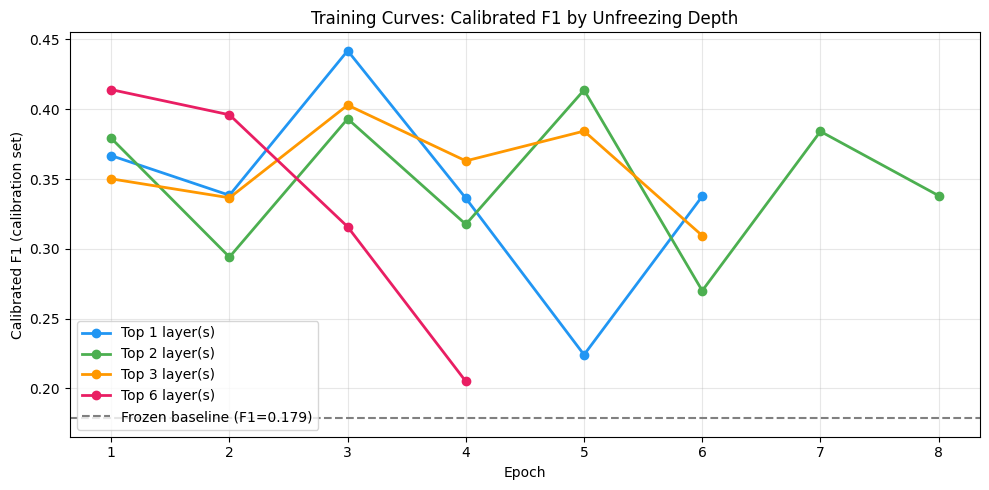

Training curves saved.


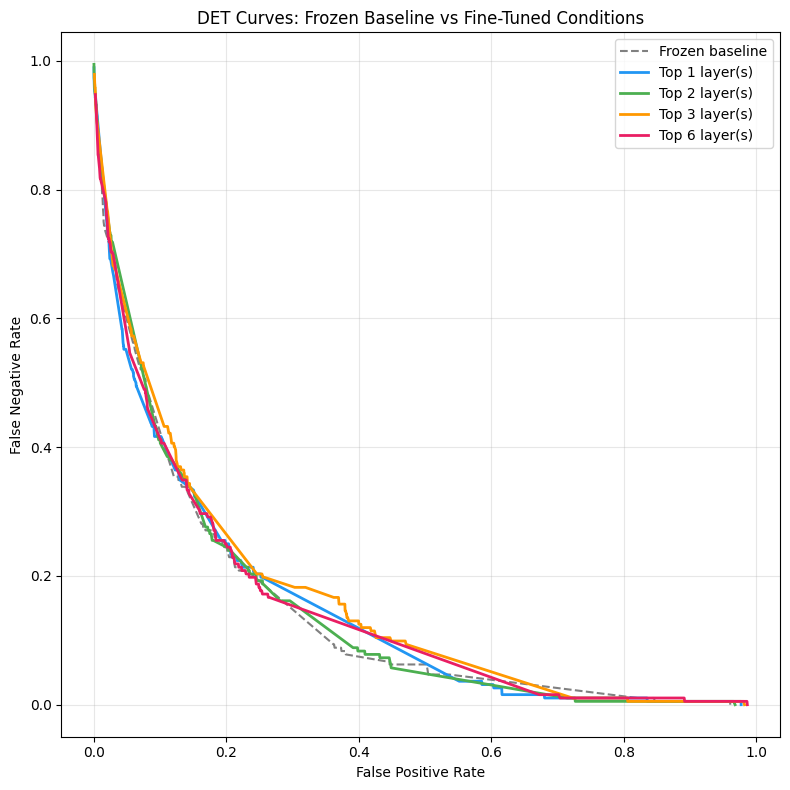

DET curves saved.

Best condition: top 1 layer(s) (cal F1=0.4419)
Fitting UMAP on fine-tuned embeddings...
Fitting UMAP on frozen embeddings...


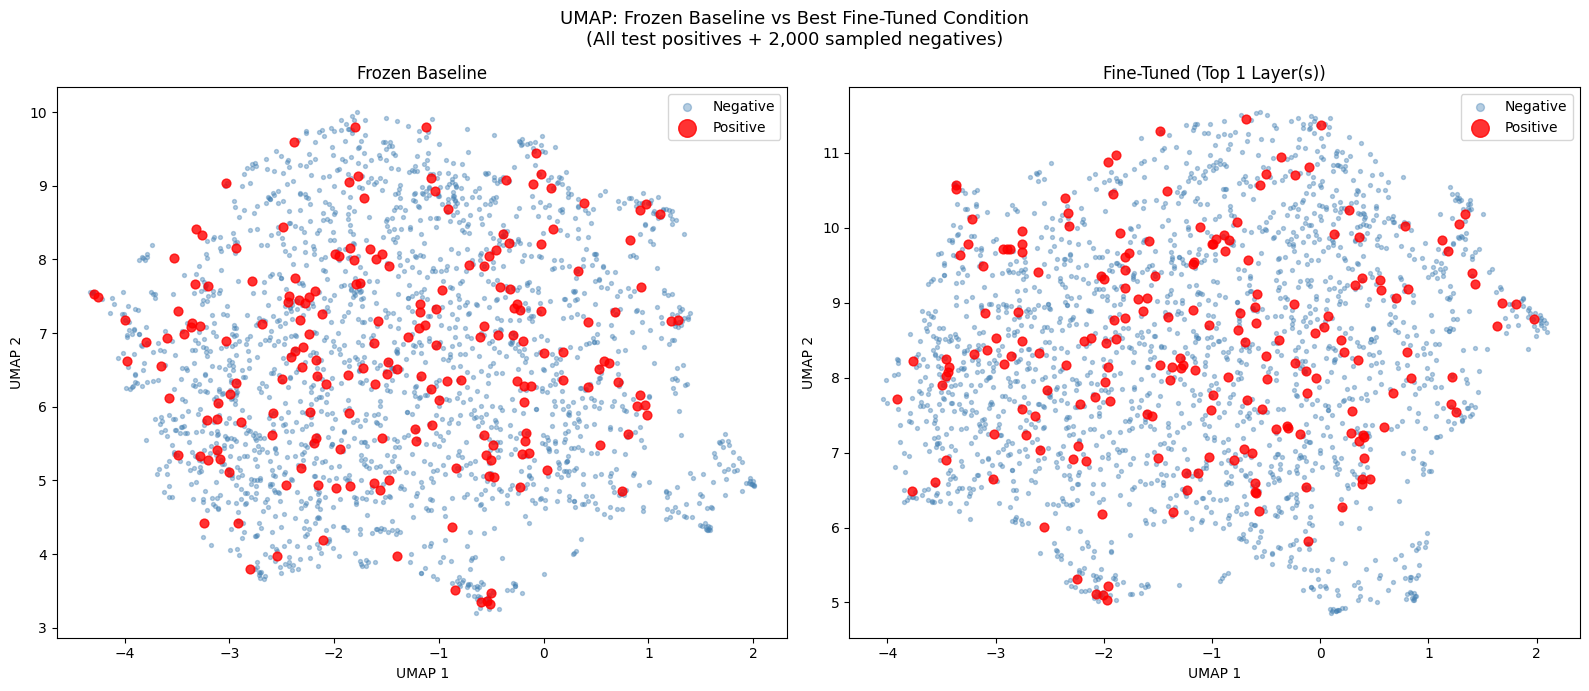

UMAP comparison saved.


In [13]:
# Cell 8: Evaluation and Visualizations
# -----------------------------------------------
# Comparative evaluation of all unfreezing conditions
# against the frozen baseline.
# -----------------------------------------------

from sklearn.metrics import det_curve, DetCurveDisplay
from sklearn.metrics import precision_score, recall_score

# -----------------------------------------------
# 8a: Full metrics table
# -----------------------------------------------
print("=" * 65)
print(f"{'Condition':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Threshold':>10}")
print("-" * 65)

# Frozen baseline row
base_prec = precision_score(y_test, y_pred_base_cal, zero_division=0)
base_rec  = recall_score(y_test, y_pred_base_cal, zero_division=0)
base_f1   = f1_score(y_test, y_pred_base_cal, zero_division=0)
print(f"{'Frozen baseline':<22} {base_prec:>10.3f} {base_rec:>8.3f} "
      f"{base_f1:>8.3f} {t_base:>10.2f}")

# Fine-tuned conditions
for n_layers in CONDITIONS:
    if n_layers not in all_results:
        continue
    r = all_results[n_layers]
    prec = precision_score(y_test, r['y_pred_test'], zero_division=0)
    rec  = recall_score(y_test, r['y_pred_test'], zero_division=0)
    f1   = f1_score(y_test, r['y_pred_test'], zero_division=0)
    print(f"{'Top '+str(n_layers)+' layer(s)':<22} {prec:>10.3f} "
          f"{rec:>8.3f} {f1:>8.3f} {r['threshold']:>10.2f}")

print("=" * 65)

# -----------------------------------------------
# 8b: Training curves — calibrated F1 per epoch
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, n_layers in enumerate(CONDITIONS):
    if n_layers not in all_results:
        continue
    history = all_results[n_layers]['history']
    epochs  = [h['epoch'] for h in history]
    cal_f1s = [h['cal_f1'] for h in history]
    ax.plot(
        epochs, cal_f1s,
        marker='o',
        color=colors[i],
        label=f"Top {n_layers} layer(s)",
        linewidth=2,
    )

# Frozen baseline reference line
ax.axhline(
    y=base_f1,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f"Frozen baseline (F1={base_f1:.3f})",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Calibrated F1 (calibration set)")
ax.set_title("Training Curves: Calibrated F1 by Unfreezing Depth")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "training_curves.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Training curves saved.")

# -----------------------------------------------
# 8c: DET curves — overlaid across all conditions
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

# Frozen baseline DET curve
fpr_base, fnr_base, _ = det_curve(y_test, y_scores_base_cal)
ax.plot(fpr_base, fnr_base,
        color='gray', linestyle='--',
        linewidth=1.5, label="Frozen baseline")

# Fine-tuned condition DET curves
for i, n_layers in enumerate(CONDITIONS):
    if n_layers not in all_results:
        continue
    r = all_results[n_layers]
    fpr, fnr, _ = det_curve(y_test, r['y_scores_test'])
    ax.plot(fpr, fnr,
            color=colors[i],
            linewidth=2,
            label=f"Top {n_layers} layer(s)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("False Negative Rate")
ax.set_title("DET Curves: Frozen Baseline vs Fine-Tuned Conditions")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "det_curves.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("DET curves saved.")

# -----------------------------------------------
# 8d: UMAP — best condition vs frozen baseline
# -----------------------------------------------

# Identify best condition by calibrated F1
best_n = max(
    [n for n in CONDITIONS if n in all_results],
    key=lambda n: all_results[n]['best_cal_f1']
)
print(f"\nBest condition: top {best_n} layer(s) "
      f"(cal F1={all_results[best_n]['best_cal_f1']:.4f})")

# Subsample for UMAP — use all positives + 2000 sampled negatives
# consistent with UMAP approach in prior notebooks
n_neg_sample = 2000
neg_idx = np.where(y_test == 0)[0]
pos_idx = np.where(y_test == 1)[0]
sampled_neg_idx = np.random.choice(neg_idx, n_neg_sample, replace=False)
plot_idx = np.concatenate([pos_idx, sampled_neg_idx])

# Fine-tuned embeddings for best condition
X_plot_ft = all_results[best_n]['X_test_ft'][plot_idx]
y_plot    = y_test[plot_idx]

print("Fitting UMAP on fine-tuned embeddings...")
reducer_ft = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
X_umap_ft  = reducer_ft.fit_transform(X_plot_ft)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: frozen baseline UMAP
# Reload frozen test embeddings for comparison
X_plot_frozen = X_test[plot_idx]
print("Fitting UMAP on frozen embeddings...")
reducer_frozen = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
X_umap_frozen  = reducer_frozen.fit_transform(X_plot_frozen)

for ax, X_umap, title in zip(
    axes,
    [X_umap_frozen, X_umap_ft],
    [f"Frozen Baseline", f"Fine-Tuned (Top {best_n} Layer(s))"]
):
    ax.scatter(
        X_umap[y_plot == 0, 0],
        X_umap[y_plot == 0, 1],
        c='steelblue', s=8, alpha=0.4, label="Negative"
    )
    ax.scatter(
        X_umap[y_plot == 1, 0],
        X_umap[y_plot == 1, 1],
        c='red', s=40, alpha=0.8, label="Positive"
    )
    ax.set_title(title)
    ax.legend(markerscale=2)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.suptitle(
    "UMAP: Frozen Baseline vs Best Fine-Tuned Condition\n"
    "(All test positives + 2,000 sampled negatives)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "umap_comparison.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("UMAP comparison saved.")

## Cell 9: Save Artifacts for Notebook 09
Saves all fine-tuned encoder weights and recomputed embeddings needed
for Notebook 09 (augmentation experiments with fine-tuned encoder).

The best performing condition is identified by calibrated F1 and its
artifacts are saved as the canonical fine-tuned baseline:
- Fine-tuned encoder weights (.pt) — for re-embedding synthetic candidates
- Recomputed train/cal/test embeddings (.npy) — drop-in replacements
  for the frozen embeddings used in Notebooks 04-07
- Calibrated scores and threshold — frozen canonical baseline for
  Notebook 09, analogous to how frozen baseline was handled here

All other conditions are also saved for reference, but Notebook 09
uses only the best condition by default.

In [ ]:
# Cell 9: Save Artifacts for Notebook 09
# -----------------------------------------------
# Saves best condition artifacts as canonical fine-tuned baseline.
# Notebook 09 loads these directly — no recomputation needed.
# -----------------------------------------------

ARTIFACTS_DIR = "data/processed/finetuned"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# -----------------------------------------------
# Identify best condition
# -----------------------------------------------
best_n = max(
    [n for n in CONDITIONS if n in all_results],
    key=lambda n: all_results[n]['best_cal_f1']
)
best_result = all_results[best_n]

print(f"Best condition: top {best_n} layer(s) "
      f"(cal F1={best_result['best_cal_f1']:.4f})")
print(f"Saving artifacts to {ARTIFACTS_DIR}/\n")

# -----------------------------------------------
# Save recomputed embeddings for best condition
# These replace the frozen .npy files in Notebook 09
# -----------------------------------------------
np.save(
    os.path.join(ARTIFACTS_DIR, "X_train_ft.npy"),
    best_result['X_train_ft']
)
np.save(
    os.path.join(ARTIFACTS_DIR, "X_cal_ft.npy"),
    best_result['X_cal_ft']
)
np.save(
    os.path.join(ARTIFACTS_DIR, "X_test_ft.npy"),
    best_result['X_test_ft']
)
print("Embeddings saved:")
print(f"  X_train_ft: {best_result['X_train_ft'].shape}")
print(f"  X_cal_ft:   {best_result['X_cal_ft'].shape}")
print(f"  X_test_ft:  {best_result['X_test_ft'].shape}")

# -----------------------------------------------
# Save calibrated scores and threshold
# Frozen canonical baseline for Notebook 09 —
# analogous to data/results/y_scores_base_cal.npy
# -----------------------------------------------
np.save(
    os.path.join(ARTIFACTS_DIR, "y_scores_ft_cal.npy"),
    best_result['y_scores_test']
)
np.save(
    os.path.join(ARTIFACTS_DIR, "t_ft.npy"),
    np.array([best_result['threshold']])
)
np.save(
    os.path.join(ARTIFACTS_DIR, "y_pred_ft.npy"),
    best_result['y_pred_test']
)
print("\nCalibrated scores and threshold saved:")
print(f"  Threshold: {best_result['threshold']:.2f}")
print(f"  y_scores_ft_cal: {best_result['y_scores_test'].shape}")

# -----------------------------------------------
# Save best model weights
# Used in Notebook 09 to re-embed synthetic candidates
# -----------------------------------------------
model_save_path = os.path.join(
    ARTIFACTS_DIR, f"best_model_{best_n}layers.pt"
)
torch.save(
    best_result['model'].state_dict(),
    model_save_path
)
print(f"\nBest model weights saved to {model_save_path}")

# -----------------------------------------------
# Save all conditions summary as JSON
# Human-readable record of all experiment results
# -----------------------------------------------
summary = {
    'best_condition': best_n,
    'frozen_baseline': {
        'f1': round(float(base_f1), 4),
        'precision': round(float(base_prec), 4),
        'recall': round(float(base_rec), 4),
        'threshold': round(float(t_base), 4),
    },
    'conditions': {}
}

for n_layers in CONDITIONS:
    if n_layers not in all_results:
        continue
    r = all_results[n_layers]
    prec = precision_score(y_test, r['y_pred_test'], zero_division=0)
    rec  = recall_score(y_test, r['y_pred_test'], zero_division=0)
    f1   = f1_score(y_test, r['y_pred_test'], zero_division=0)
    summary['conditions'][str(n_layers)] = {
        'f1': round(float(f1), 4),
        'precision': round(float(prec), 4),
        'recall': round(float(rec), 4),
        'threshold': round(float(r['threshold']), 4),
        'best_cal_f1': round(float(r['best_cal_f1']), 4),
        'epochs_run': len(r['history']),
    }

summary_path = os.path.join(RESULTS_DIR, "experiment_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\nExperiment summary saved to {summary_path}")

# -----------------------------------------------
# Final confirmation
# -----------------------------------------------
print("\n" + "="*60)
print("Notebook 08 complete.")
print(f"Best condition: top {best_n} unfrozen layer(s)")
print(f"Best calibrated F1: {best_result['best_cal_f1']:.4f} "
      f"(frozen baseline: {base_f1:.4f})")
print(f"All artifacts saved to {ARTIFACTS_DIR}/")
print("Ready for Notebook 09: augmentation with fine-tuned encoder.")
print("="*60)

## Cells 10-11: Pre-Prep for Next Run
Clean up current run artifacts and update hyperparameters for rerun
with lr=5e-6 and patience=2. Run these cells after completing the
current run and before disconnecting the Colab runtime.

In [14]:
# Cell 10: Clear current run artifacts
# -----------------------------------------------
# Deletes all saved condition results from the current run
# so Cell 7's resume logic doesn't skip them next session.
# Only clears finetuning results — baseline artifacts are untouched.
# -----------------------------------------------

import glob

finetuning_dir = "data/results/finetuning"

files_to_delete = (
    glob.glob(os.path.join(finetuning_dir, "condition_*.pkl")) +
    glob.glob(os.path.join(finetuning_dir, "model_*.pt")) +
    glob.glob(os.path.join(finetuning_dir, "history_*.json")) +
    glob.glob(os.path.join(finetuning_dir, "*.png"))
)

if not files_to_delete:
    print("No files found to delete — already clean.")
else:
    for f in files_to_delete:
        os.remove(f)
        print(f"Deleted: {os.path.basename(f)}")
    print(f"\nCleared {len(files_to_delete)} files.")
    print("Cell 7 will run all conditions fresh next session.")

Deleted: condition_1layers.pkl
Deleted: condition_2layers.pkl
Deleted: condition_3layers.pkl
Deleted: condition_6layers.pkl
Deleted: model_1layers.pt
Deleted: model_2layers.pt
Deleted: model_3layers.pt
Deleted: model_6layers.pt
Deleted: history_1layers.json
Deleted: history_2layers.json
Deleted: history_3layers.json
Deleted: history_6layers.json
Deleted: training_curves.png
Deleted: det_curves.png
Deleted: umap_comparison.png

Cleared 15 files.
Cell 7 will run all conditions fresh next session.


In [15]:
# Cell 11: Verify hyperparameter updates and confirm readiness
# -----------------------------------------------
# Confirms that Cell 5 has been updated with new hyperparameters
# before disconnecting. Does not run training — inspection only.
# -----------------------------------------------

import inspect

# Extract default hyperparameters from fine_tune_condition signature
sig = inspect.signature(fine_tune_condition)
params = {k: v.default for k, v in sig.parameters.items()}

print("=== fine_tune_condition hyperparameters ===")
for k, v in params.items():
    print(f"  {k}: {v}")

# Verify lr and patience are updated
lr_ok      = params.get('lr') == 5e-6
patience_ok = params.get('patience') == 2

print(f"\nlr=5e-6:     {'✓' if lr_ok else '✗ UPDATE CELL 5'}")
print(f"patience=2:  {'✓' if patience_ok else '✗ UPDATE CELL 5'}")

if lr_ok and patience_ok:
    print("\nAll hyperparameters confirmed. Ready for next session.")
    print("Next steps:")
    print("  1. Commit notebook locally")
    print("  2. Disconnect Colab runtime")
    print("  3. Next session: connect runtime, run cells 0a-6, then Cell 7")
else:
    print("\nUpdate Cell 5 before proceeding.")

=== fine_tune_condition hyperparameters ===
  n_layers: <class 'inspect._empty'>
  n_epochs: 10
  lr: 5e-06
  patience: 2
  batch_size: 16

lr=5e-6:     ✓
patience=2:  ✓

All hyperparameters confirmed. Ready for next session.
Next steps:
  1. Commit notebook locally
  2. Disconnect Colab runtime
  3. Next session: connect runtime, run cells 0a-6, then Cell 7
